# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [145]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [146]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [147]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [148]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**

El Data Frame cuenta con 9 columnas y 40,000 registros.

Es de suma importancia destacar que no existen datos nulos en ninguna de las columnas del Data Frame; es decir, todas las columnas cuentan con el mismo número de registros.

Aunado a ello, todos los tipos de columnas son correctos y nos permitirá realizar su análisis sin ningún impedimento.


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [149]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [150]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [151]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [152]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [153]:
# Resumen estadístico de usuarios que se convirtieron
df_convertidos = df[df['converted'] == 1]

df_convertidos['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

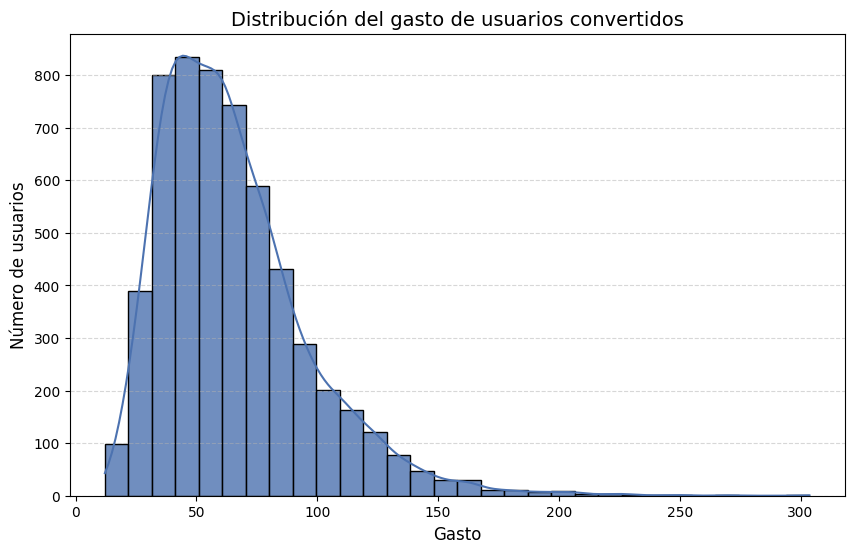

In [154]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_convertidos,
    x='gasto',
    bins=30,
    kde=True,
  
  color="#4C72B0",
    edgecolor="black",
    alpha=0.8

)

plt.title("Distribución del gasto de usuarios convertidos", fontsize=14)
plt.xlabel("Gasto", fontsize=12)
plt.ylabel("Número de usuarios", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

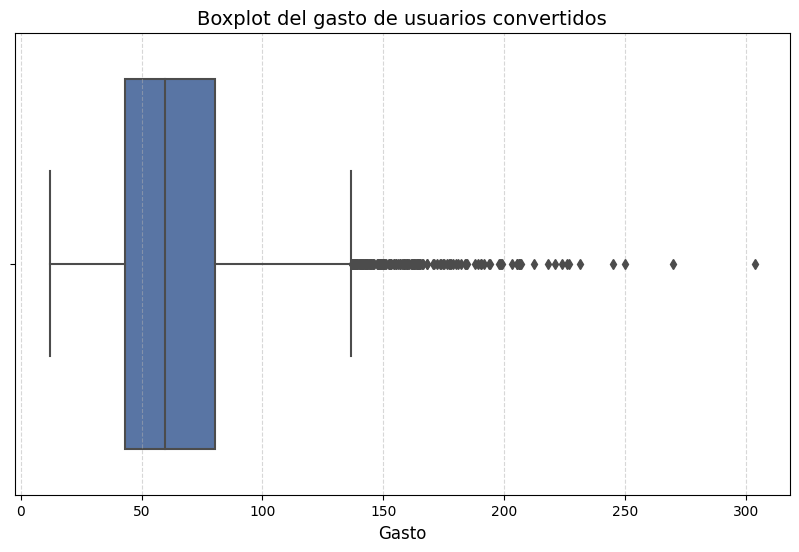

In [155]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df_convertidos['gasto'],
    color="#4C72B0"
)

plt.title("Boxplot del gasto de usuarios convertidos", fontsize=14)
plt.xlabel("Gasto", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).


Distribución de la variable: landing

Tabla de distribución:
   Conteo  Porcentaje (%)
B   20018           50.04
A   19982           49.96

Conversiones (% por fila):
converted      0      1
landing                
A          87.43  12.57
B          84.04  15.96


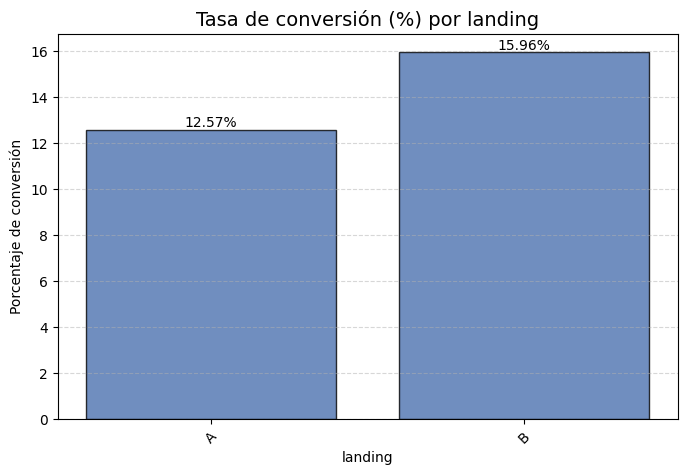


Distribución de la variable: region

Tabla de distribución:
           Conteo  Porcentaje (%)
Norte       11166           27.92
Centro       9613           24.03
Sur          8039           20.10
Occidente    6398           16.00
Oriente      4784           11.96

Conversiones (% por fila):
converted      0      1
region                 
Centro     85.48  14.52
Norte      85.38  14.62
Occidente  85.78  14.22
Oriente    86.31  13.69
Sur        86.17  13.83


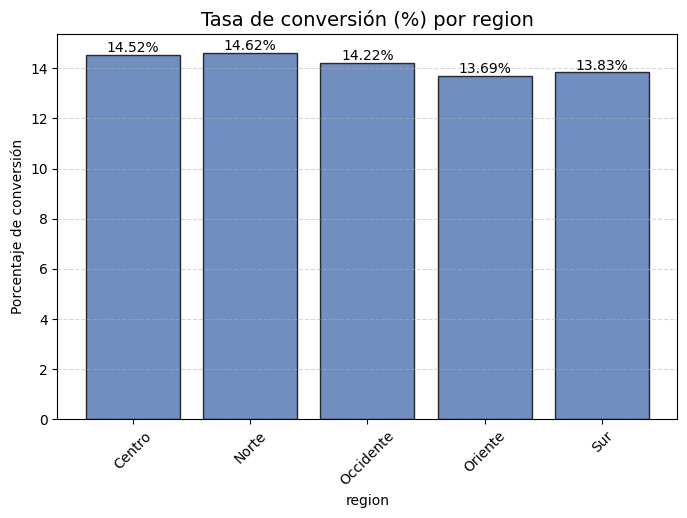


Distribución de la variable: dispositivo

Tabla de distribución:
         Conteo  Porcentaje (%)
Mobile    24829           62.07
Desktop   15171           37.93

Conversiones (% por fila):
converted        0      1
dispositivo              
Desktop      83.90  16.10
Mobile       86.86  13.14


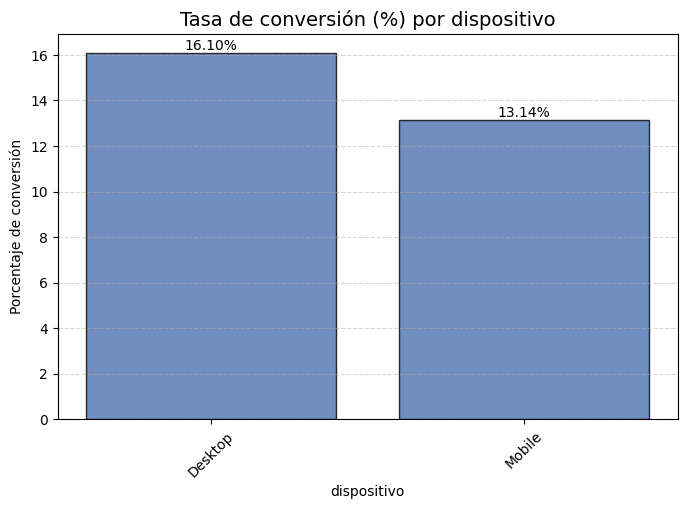


Distribución de la variable: traffic_source

Tabla de distribución:
          Conteo  Porcentaje (%)
Organic    17987           44.97
Ads        11935           29.84
Email       6123           15.31
Referral    3955            9.89

Conversiones (% por fila):
converted           0      1
traffic_source              
Ads             85.26  14.74
Email           85.01  14.99
Organic         86.21  13.79
Referral        86.12  13.88


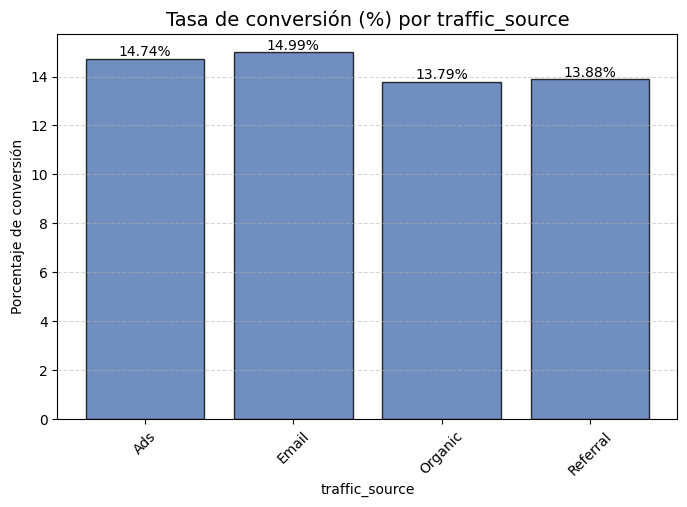


Distribución de la variable: user_type

Tabla de distribución:
            Conteo  Porcentaje (%)
Nuevo        26033           65.08
Recurrente   13967           34.92

Conversiones (% por fila):
converted       0      1
user_type               
Nuevo       85.64  14.36
Recurrente  85.91  14.09


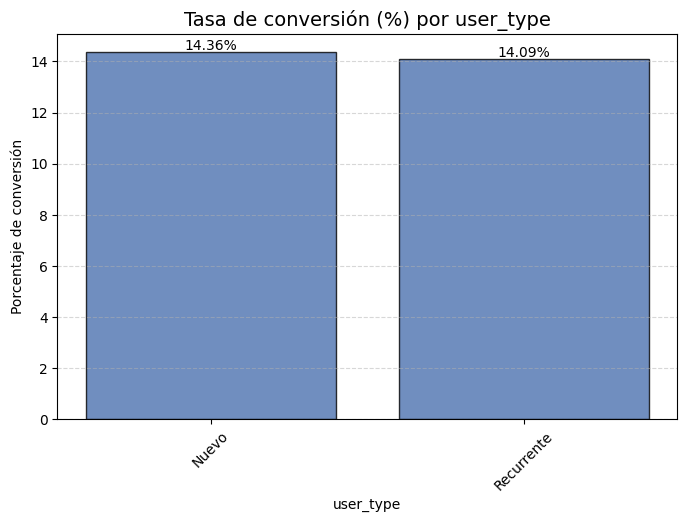

In [156]:
# Explorar variables categóricas y cómo se distribuyen

columnas_categoricas = [
    'landing',
    'region',
    'dispositivo',
    'traffic_source',
    'user_type'
]

def explorar_categoricas(df, columnas):

    for col in columnas:

        print("\n" + "="*60)
        print(f"Distribución de la variable: {col}")
        print("="*60)

        # Tabla de distribución
        tabla = df[col].value_counts().to_frame(name='Conteo')
        tabla['Porcentaje (%)'] = tabla['Conteo'] / tabla['Conteo'].sum() * 100

        print("\nTabla de distribución:")
        print(tabla.round(2))

        # Crosstab
        crosstab = pd.crosstab(df[col], df['converted'], normalize='index') * 100

        print("\nConversiones (% por fila):")
        print(crosstab.round(2))  # solo redondeo visual

        # Valores para el gráfico
        tasa_conversion = crosstab[1]

        plt.figure(figsize=(8,5))

        bars = plt.bar(
            tasa_conversion.index,
            tasa_conversion.values,
            color="#4C72B0",
            edgecolor="black",
            alpha=0.8
        )

        plt.title(f"Tasa de conversión (%) por {col}", fontsize=14)
        plt.xlabel(col)
        plt.ylabel("Porcentaje de conversión")

        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)

        # Etiquetas
        for bar, valor in zip(bars, tasa_conversion.values):
            plt.text(
                bar.get_x() + bar.get_width()/2,
                valor,
                f"{valor:.2f}%",
                ha='center',
                va='bottom'
            )

        plt.show()


explorar_categoricas(df, columnas_categoricas)

✍️ **Insights**

- Contamos con 40,000 registros únicos que podemos identificar a través de su `user_id`.

- Para la columna `date` contamos con 28 registros únicos de fecha teniendo como la más recurrente: 24 de enero de 2026. Aunado a ello, podemos detectar un rango de fechas que van desde el 1° al 28 de enero de 2026.

- Como primer paso se obtuvo el resumen estadístico de la variable `gasto`. Sin embargo, los resultados iniciales incluían a los usuarios que no realizaron una conversión, es decir, aquellos cuyo monto de gasto es igual a cero. Por esta razón, se calculó nuevamente el resumen estadístico considerando únicamente a los clientes que sí realizaron una conversión.

    A partir de este nuevo análisis se observó que el gasto promedio de los clientes convertidos es de 65.37, mientras que el 75% de los valores se encuentran en un rango aproximado entre 12.12 y 80.37. Asimismo, la desviación estándar es de 65.37, lo que indica una alta variabilidad en los montos de gasto entre los usuarios.

    Es importante señalar que esta variable presenta valores atípicos (outliers), los cuales pueden corresponder a clientes de alto gasto o heavy spenders. Esta situación puede observarse con mayor claridad en las visualizaciones realizadas, como el histograma y el boxplot.

    Con base en esta información, sería recomendable profundizar en el análisis de estos clientes para identificar las características o condiciones que influyen en su mayor nivel de gasto. Esto permitiría diseñar estrategias específicas que incentiven comportamientos de compra similares en otros segmentos de usuarios.

- Se muestra una distribución equilibrada entre ambas versiones de `landing` lo que permite que el experimento esté balanceado. En lo que refiere a la tasa de conversión, la versión de página B muestra 3.39 más puntos de conversión que la A.

- La mayor concentración de clientes se encuentra en las `regiones` Norte y Centro, que en conjunto representan el 51.95% del total de usuarios. No obstante, al analizar la tasa de conversión, se observa un comportamiento relativamente homogéneo entre todas las regiones.

    A partir de esta información, sería pertinente analizar y comparar las estrategias y campañas publicitarias implementadas en cada región, con el objetivo de determinar si la menor participación de mercado observada en Occidente y Oriente se debe a una menor exposición o inversión en dichas zonas.

- La mayoría de los usuarios accede a la plataforma a través de `dispositivos` móviles, que representan el 62.07% del total del tráfico. Sin embargo, al analizar la tasa de conversión por dispositivo, se observa que los usuarios que navegan desde computadora de escritorio presentan un mayor porcentaje de conversión (16.10%) en comparación con los usuarios móviles.

    Este resultado sugiere la necesidad de profundizar en el análisis de la experiencia de usuario entre ambos dispositivos, con el objetivo de identificar posibles diferencias en el proceso de navegación o conversión. En caso de confirmarse estas discrepancias, sería recomendable optimizar el funnel de conversión para garantizar una experiencia más homogénea, permitiendo que los usuarios puedan completar la conversión con la misma facilidad independientemente del dispositivo desde el cual accedan.

- Para la columna `traffic_source` aunque el tráfico orgánico genera el mayor volumen de usuarios (44.97%), los canales de Email y Ads parecen ser más efectivos para convertir visitantes en clientes (14.99% y 14.74% respectivamente). En este sentido, podría resultar conveniente profundizar en el análisis de las estrategias implementadas en estos canales, con el fin de identificar las prácticas que favorecen la conversión y evaluar la posibilidad de replicarlas o reforzarlas en otros canales de adquisición.

- La tasa de conversión según el tipo de usuario (`user_type`) es muy similar entre ambos segmentos. No obstante, al considerar el volumen de usuarios, se observa que los usuarios nuevos representan el 65.08% del total, lo que podría reflejar la efectividad de las estrategias actuales de adquisición de clientes.

    En este sentido, mejorar la tasa de conversión dentro de este segmento podría generar un impacto significativo en el número total de conversiones, dado su mayor peso dentro del tráfico total.

    Asimismo, sería conveniente profundizar en el análisis del comportamiento de ambos grupos de usuarios, con el objetivo de identificar oportunidades que permitan fortalecer las estrategias de fidelización y fomentar una mayor recurrencia.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [157]:
# Gasto por versión
gasto_A = df[(df['landing']=='A') & (df['converted']==1)]['gasto']
gasto_B = df[(df['landing']=='B') & (df['converted']==1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Pruebas Levene y t-Test

**Hipótesis:**
- **Hipótesis nula (H₀):** el gasto promedio y las varianzas de gasto entre A y B son iguales.
- **Hipótesis alternativa (H₁):** el gasto promedio y las varianzas de gasto entre A y B muestran diferencias.

In [158]:
from scipy.stats import ttest_ind, levene

alpha = 0.05  # umbral de significancia

# 1 Prueba de igualdad de varianzas
l_stat, p_value_var = levene(gasto_A, gasto_B)
print("----- PRUEBA DE LEVENE -----")
print(f"Estadístico de Levene: {l_stat:}")
print(f"p-value: {p_value_var:}")

# Interpretación
if p_value_var < alpha:
    print("Rechazamos H0: hay evidencia de varianzas diferentes.")
    equal_var = False
else:
    print("No rechazamos H0: no hay evidencia de varianzas diferentes.")
    equal_var = True

# 2 Prueba t según resultado de Levene
t_stat, p_value_t = ttest_ind(gasto_A, gasto_B, equal_var=equal_var)
print("\n----- PRUEBA T -----")
print(f"Estadístico t: {t_stat:}")
print(f"p-value: {p_value_t:}")

# Interpretación de la prueba t
if p_value_t < alpha:
    print("Rechazamos H0: existe una diferencia estadísticamente significativa entre las medias.")
else:
    print("No rechazamos H0: no se encontró una diferencia estadísticamente significativa entre las medias.")

# 3 Medias 
print("\n----- MEDIAS -----")
print(f"Media gasto A: {gasto_A.mean():.2f}")
print(f"Media gasto B: {gasto_B.mean():.2f}")
print('La diferencia es de: ', gasto_B.mean() - gasto_A.mean())


----- PRUEBA DE LEVENE -----
Estadístico de Levene: 29.17646453202917
p-value: 6.875301988016449e-08
Rechazamos H0: hay evidencia de varianzas diferentes.

----- PRUEBA T -----
Estadístico t: -9.48101092267275
p-value: 3.627602231521493e-21
Rechazamos H0: existe una diferencia estadísticamente significativa entre las medias.

----- MEDIAS -----
Media gasto A: 61.09
Media gasto B: 68.75
La diferencia es de:  7.658787597864624


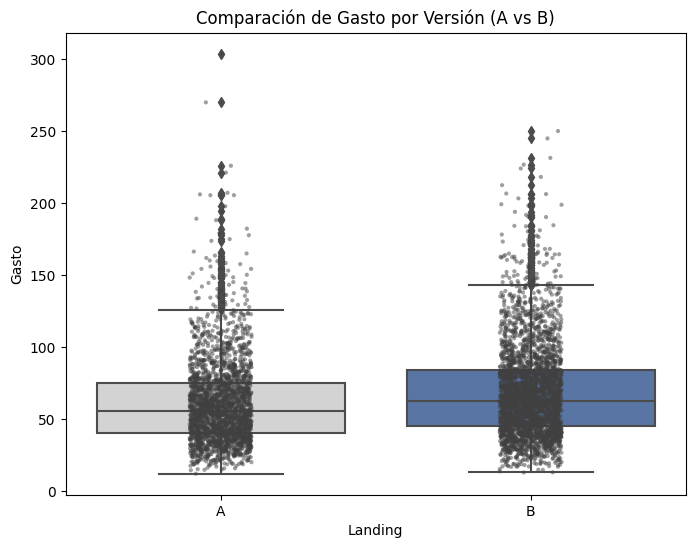

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear DataFrame para graficar
df_plot = pd.DataFrame({
    'gasto': pd.concat([gasto_A, gasto_B], ignore_index=True),
    'landing': ['A']*len(gasto_A) + ['B']*len(gasto_B)
})

# Definir paleta personalizada: A gris, B azul #4C72B0
palette_custom = {'A':'lightgray', 'B':'#4C72B0'}

# Configuración del gráfico
plt.figure(figsize=(8,6))
sns.boxplot(x='landing', y='gasto', data=df_plot, palette=palette_custom)
sns.stripplot(x='landing', y='gasto', data=df_plot, color='0.25', alpha=0.5, jitter=True, size=3)

plt.title('Comparación de Gasto por Versión (A vs B)')
plt.ylabel('Gasto')
plt.xlabel('Landing')
plt.show()


### 📝 Conclusión e interpretación

**Decisión:**  
Basándonos en los resultados arrojados a partir de las pruebas Levene y t-Test; *rechazamos la Hipótesis nula (H₀)*. En ambos casos el p-value fue extremadamente pequeño proporcionando evidencia estadísticamente significativa de que tanto la varianza como las medias de gasto son diferentes.


**Interpretación de negocio:**  
Los resultados presentados en el apartado anterior indican que la página B tiene un gasto promedio superior al de la página A (7.66 unidades). Esto sugiere que la versión B está funcionando mejor en términos de gasto promedio entre los usuarios que realizan una conversión. Además, el gráfico muestra que la página A presenta un mayor número de valores atípicos, los cuales podrían estar influyendo en el monto registrado.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**
- **Hipótesis nula (H₀):** la tasa de conversión es igual en ambas páginas. Cualquier diferencia se debe al azar del muestreo.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre ambas páginas. Hay un factor que influye en la decisión de compra.

In [160]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()
totales = df.groupby('landing')['converted'].count()

# Total de clientes convertidos (todas las páginas)
total_convertidos = df['converted'].sum()

# Total de usuarios en el dataset
total_usuarios = len(df)

# Mostrar resultados

# Total de clientes convertidos (todas las páginas)
total_convertidos = df['converted'].sum()

# Total de usuarios en el dataset
total_usuarios = len(df)

print("\n=== Totales generales ===")
print(f"Total de clientes convertidos (todas las páginas): {total_convertidos}")
print(f"Total de usuarios en el dataset: {total_usuarios}\n")

print("=== Usuarios convertidos por página ===")
print(conversiones, "\n")

print("=== Total de usuarios por página ===")
print(totales, "\n")

from statsmodels.stats.proportion import proportions_ztest

# Extraer datos para A y B
conteos = [conversiones['A'], conversiones['B']]
num_observaciones = [totales['A'], totales['B']]

# Calcular tasas de conversión
tasa_A = conteos[0] / num_observaciones[0]
tasa_B = conteos[1] / num_observaciones[1]
diferencia = tasa_B - tasa_A

# Prueba Z
z_stat, p_value = proportions_ztest(count=conteos, nobs=num_observaciones)

# Resultados
print(f"Tasa página A: {tasa_A:.2%}")
print(f"Tasa página B: {tasa_B:.2%}")
print(f"Diferencia (B - A): {diferencia:.3f}""\n")
print(f"Estadístico Z: {z_stat:.3f}")
print(f"Valor p: {p_value}")

# Significancia
alpha = 0.05
if p_value < alpha:
    print("\n""Rechazamos la hipótesis nula: hay evidencia de una diferencia significativa.")
else:
    print("\n""No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia significativa.")




=== Totales generales ===
Total de clientes convertidos (todas las páginas): 5706
Total de usuarios en el dataset: 40000

=== Usuarios convertidos por página ===
landing
A    2512
B    3194
Name: converted, dtype: int64 

=== Total de usuarios por página ===
landing
A    19982
B    20018
Name: converted, dtype: int64 

Tasa página A: 12.57%
Tasa página B: 15.96%
Diferencia (B - A): 0.034

Estadístico Z: -9.677
Valor p: 3.7629765627523803e-22

Rechazamos la hipótesis nula: hay evidencia de una diferencia significativa.


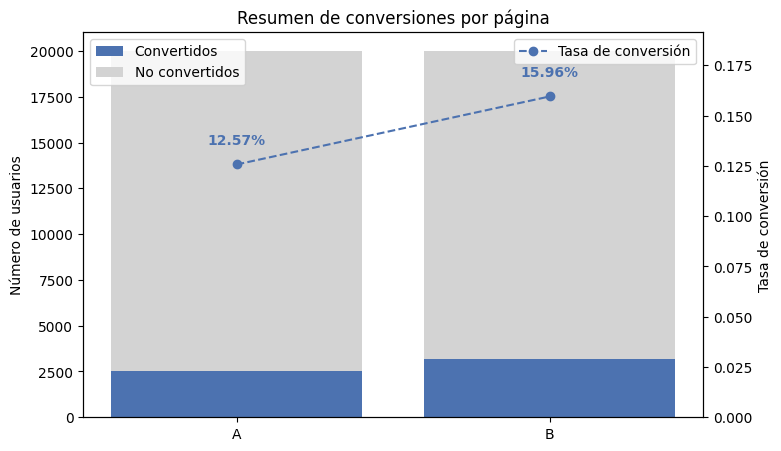

In [161]:
import numpy as np

# Datos
landing_pages = ['A', 'B']
convertidos = [conteos[0], conteos[1]]
no_convertidos = [num_observaciones[0]-conteos[0], num_observaciones[1]-conteos[1]]
tasas = [tasa_A, tasa_B]

# Crear gráfico de barras apiladas
fig, ax1 = plt.subplots(figsize=(8,5))

# Barras de convertidos/no convertidos

ax1.bar(landing_pages, convertidos, label='Convertidos', color='#4C72B0')
ax1.bar(landing_pages, no_convertidos, bottom=convertidos, label='No convertidos', color='lightgray')

ax1.set_ylabel("Número de usuarios")
ax1.set_title("Resumen de conversiones por página")
ax1.legend(loc='upper left')

# Crear eje secundario para tasa de conversión
ax2 = ax1.twinx()
ax2.plot(landing_pages, tasas, color='#4C72B0', marker='o', linestyle='--', label='Tasa de conversión')
ax2.set_ylabel("Tasa de conversión")
ax2.set_ylim(0, max(tasas)*1.2)
for i, v in enumerate(tasas):
    ax2.text(i, v+0.01, f"{v:.2%}", ha='center', color='#4C72B0', fontweight='bold')

ax2.legend(loc='upper right')

plt.show()

### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p es mucho menor que 0.05, *rechazamos la hipótesis nula (H₀)*, lo que indica que la diferencia entre las páginas es estadísticamente significativa.

**Interpretación de negocio:**  
La empresa presenta una conversión global del 14.3% (5,706 usuarios convertidos); dicha conversión esta compuesta de la siguiente manera:

- La página A tuvo 2,512 usuarios convertidos de 19,982 visitantes (12.57% de conversión).

- La página B tuvo 3,194 usuarios convertidos de 20,018 visitantes (15.96% de conversión).

La diferencia de tasa de conversión entre B y A es de 3.4 puntos porcentuales, mostrando que la página B cuenta con un mejor desempeño. Esto sugiere que la versión B es más efectiva para convertir usuarios y podría considerarse como la opción preferida para aumentar ingresos o registros.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.


### Prueba chi-cuadrada (Chi²)

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las dos variables (son independientes).
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las dos variables (no son independientes).


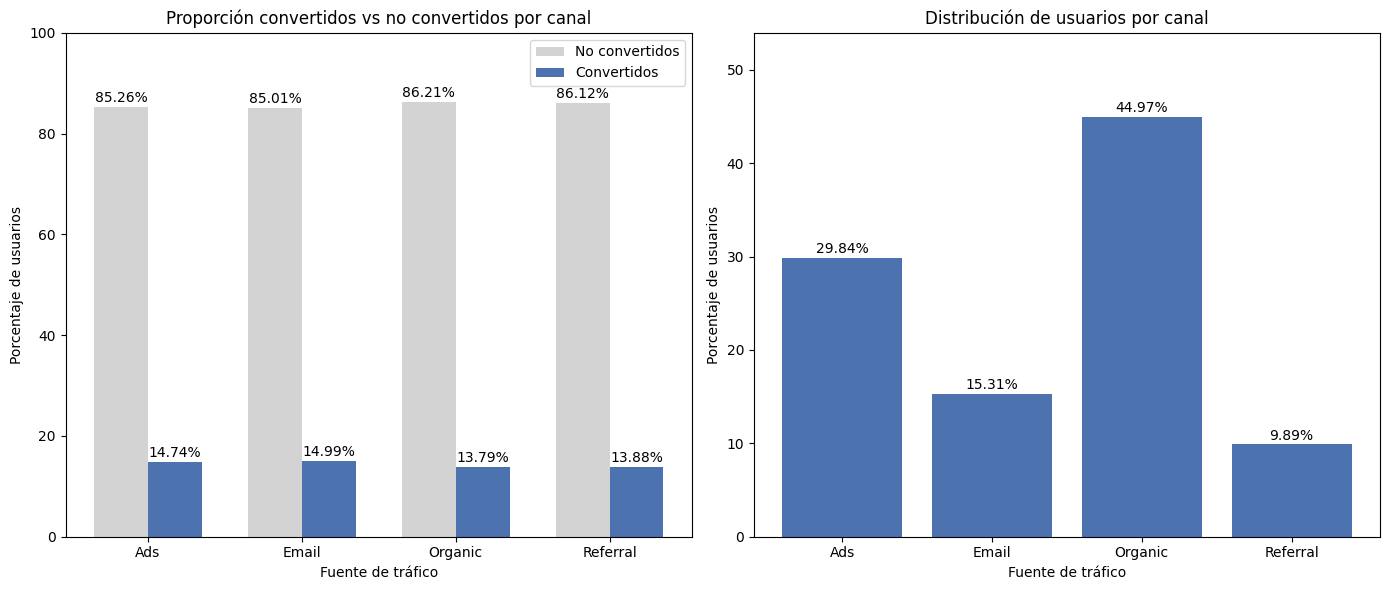

In [162]:
# Tabla de proporciones por canal
tabla_proporcion = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

no_convertidos = tabla_proporcion[0]
convertidos = tabla_proporcion[1]

x = np.arange(len(tabla_proporcion.index))
width = 0.35

# Distribución total de usuarios por canal
dist_usuarios = df['traffic_source'].value_counts(normalize=True).sort_index() * 100

# Crear figura con dos gráficos
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# ---- Gráfico 1: proporción convertidos vs no convertidos ----
bars1 = ax[0].bar(x - width/2, no_convertidos, width,
                  label='No convertidos', color='lightgray')

bars2 = ax[0].bar(x + width/2, convertidos, width,
                  label='Convertidos', color='#4C72B0')

# Etiquetas
for bar in bars1:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, height + 1,
               f'{height:.2f}%', ha='center')

for bar in bars2:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, height + 1,
               f'{height:.2f}%', ha='center')

ax[0].set_xticks(x)
ax[0].set_xticklabels(tabla_proporcion.index)
ax[0].set_ylim(0,100)
ax[0].set_ylabel("Porcentaje de usuarios")
ax[0].set_xlabel("Fuente de tráfico")
ax[0].set_title("Proporción convertidos vs no convertidos por canal")
ax[0].legend()

# ---- Gráfico 2: distribución total de usuarios por canal ----
bars = ax[1].bar(dist_usuarios.index, dist_usuarios, color='#4C72B0')

for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height + 0.5,
               f'{height:.2f}%', ha='center')

ax[1].set_ylim(0, max(dist_usuarios)*1.2)
ax[1].set_ylabel("Porcentaje de usuarios")
ax[1].set_xlabel("Fuente de tráfico")
ax[1].set_title("Distribución de usuarios por canal")

plt.tight_layout()
plt.show()



In [163]:
# Tabla de contingencia
tabla = pd.crosstab(df["traffic_source"], df["converted"])
print(tabla)

# Prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")

print("\nFrecuencias esperadas:")
print(expected)

alpha = 0.05

if p_value < alpha:
    print("\nRechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("\nNo rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]

Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
Los resultados muestran que existe una relación estadísticamente significativa entre la fuente de tráfico y la conversión. La prueba chi-cuadrada arroja un valor p = 0.034, menor al nivel de significancia de 0.05, por lo que *se rechaza la hipótesis nula de independencia (H₀)*. Esto indica que el canal de adquisición influye en la probabilidad de que un usuario convierta.

**Interpretación de negocio:**  

Al analizar los datos observados frente a las frecuencias esperadas, se observan algunos patrones relevantes:

- Ads presenta ligeramente más conversiones de las esperadas (1759 observadas vs. 1702 esperadas), lo que sugiere que este canal podría estar generando un rendimiento ligeramente superior al esperado.

- Email muestra más conversiones de las esperadas (918 vs. 873), lo que indica que, aunque su volumen de tráfico es menor, su eficiencia en conversión podría ser relativamente alta.

- Organic tiene menos conversiones de las esperadas (2480 vs. 2566), lo que sugiere que, a pesar de generar el mayor volumen de tráfico, su tasa de conversión es ligeramente inferior a la esperada.

- Referral se encuentra cercano a lo esperado, con diferencias pequeñas entre valores observados y esperados.

Estos resultados sugieren que la estrategia de marketing podría beneficiarse de optimizar o reforzar los canales con mejor desempeño relativo en conversiones, mientras se revisa la calidad del tráfico proveniente de canales con mayor volumen.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba chi-cuadrada (Chi²)

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre las dos variables (son independientes).
- **Hipótesis alternativa (H₁):** Sí existe una relación entre las dos variables (no son independientes).

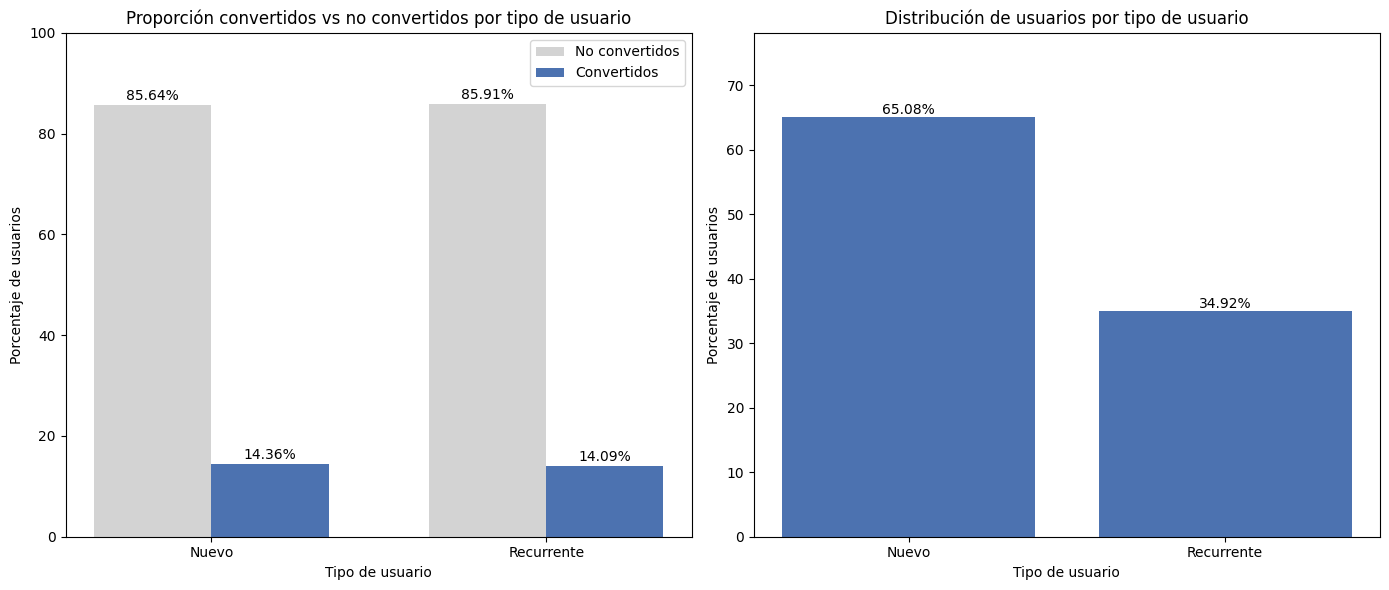

In [164]:
# Tabla de proporciones por canal
tabla_proporcion2 = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

no_convertidos2 = tabla_proporcion2[0]
convertidos2 = tabla_proporcion2[1]

x = np.arange(len(tabla_proporcion2.index))
width = 0.35

# Distribución total de usuarios por canal
dist_usuarios2 = df['user_type'].value_counts(normalize=True).sort_index() * 100

# Crear figura con dos gráficos
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# ---- Gráfico 1: proporción convertidos vs no convertidos ----
bars1 = ax[0].bar(x - width/2, no_convertidos2, width,
                  label='No convertidos', color='lightgray')

bars2 = ax[0].bar(x + width/2, convertidos2, width,
                  label='Convertidos', color='#4C72B0')

# Etiquetas
for bar in bars1:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, height + 1,
               f'{height:.2f}%', ha='center')

for bar in bars2:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, height + 1,
               f'{height:.2f}%', ha='center')

ax[0].set_xticks(x)
ax[0].set_xticklabels(tabla_proporcion2.index)
ax[0].set_ylim(0,100)
ax[0].set_ylabel("Porcentaje de usuarios")
ax[0].set_xlabel("Tipo de usuario")
ax[0].set_title("Proporción convertidos vs no convertidos por tipo de usuario")
ax[0].legend()

# ---- Gráfico 2: distribución total de usuarios por canal ----
bars = ax[1].bar(dist_usuarios2.index, dist_usuarios2, color='#4C72B0')

for bar in bars:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, height + 0.5,
               f'{height:.2f}%', ha='center')

ax[1].set_ylim(0, max(dist_usuarios2)*1.2)
ax[1].set_ylabel("Porcentaje de usuarios")
ax[1].set_xlabel("Tipo de usuario")
ax[1].set_title("Distribución de usuarios por tipo de usuario")

plt.tight_layout()
plt.show()

In [165]:
# Tabla de contingencia
tabla2 = pd.crosstab(df["user_type"], df["converted"])
print(tabla2)

# Prueba chi-cuadrada
chi2_stat, p_value, dof, expected = chi2_contingency(tabla2)

print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")

print("\nFrecuencias esperadas:")
print(expected)

alpha = 0.05

if p_value < alpha:
    print("\nRechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("\nNo rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.


### 📝 Conclusión e interpretación

**Decisión:**  
No se encontró evidencia estadísticamente significativa de que el tipo de usuario (nuevo vs. recurrente) esté asociado con la probabilidad de conversión (p = 0.474). Las conversiones observadas son muy similares a las esperadas bajo independencia, lo que sugiere que los usuarios nuevos y recurrentes presentan tasas de conversión comparables.

**Interpretación de negocio:**  
El tipo de usuario no parece ser un factor determinante en la conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

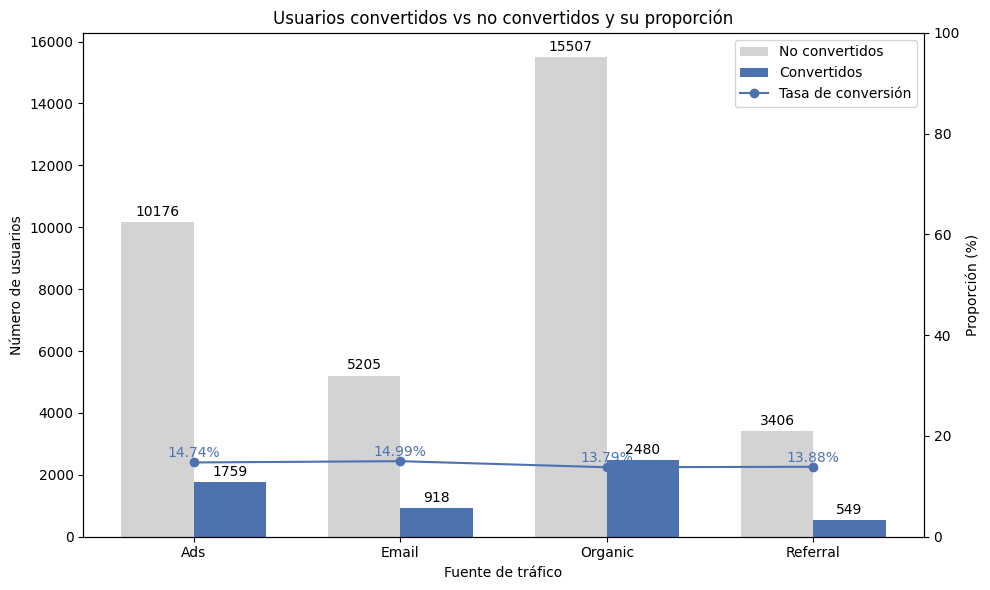

In [166]:

# Conteos absolutos
tabla_conteos = pd.crosstab(df['traffic_source'], df['converted'])

no_convertidos_abs = tabla_conteos[0]
convertidos_abs = tabla_conteos[1]

# Proporciones
tabla_proporcion = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')
prop_convertidos = tabla_proporcion[1]

x = np.arange(len(tabla_conteos.index))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10,6))

# ---- Barras (cantidad absoluta) ----
bars1 = ax1.bar(x - width/2, no_convertidos_abs, width,
                label='No convertidos', color='lightgray')

bars2 = ax1.bar(x + width/2, convertidos_abs, width,
                label='Convertidos', color='#4C72B0')

# Mostrar conteo de usuarios en las barras
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'{int(height)}', ha='center')

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'{int(height)}', ha='center')

ax1.set_ylabel("Número de usuarios")
ax1.set_xlabel("Fuente de tráfico")
ax1.set_xticks(x)
ax1.set_xticklabels(tabla_conteos.index)
ax1.set_title("Usuarios convertidos vs no convertidos y su proporción")

# ---- Segundo eje para proporciones ----
ax2 = ax1.twinx()

ax2.plot(x, prop_convertidos*100, marker='o', color='#4C72B0', label='Tasa de conversión')

ax2.set_ylabel("Proporción (%)")
ax2.set_ylim(0,100)

# Mostrar porcentaje en la línea
for i, v in enumerate(prop_convertidos*100):
    ax2.text(i, v+1, f"{v:.2f}%", ha='center', color='#4C72B0')

# Leyenda combinada
lines, labels = ax2.get_legend_handles_labels()
bars, labels2 = ax1.get_legend_handles_labels()
ax1.legend(bars + lines, labels2 + labels, loc='upper right')

plt.tight_layout()
plt.show()


✍️ **Comentario**:


El canal Organic concentra la mayor parte del tráfico y también el mayor número absoluto de conversiones (2,480). Sin embargo, su tasa de conversión (13.79%) es menor que la de otros canales, lo que sugiere que, aunque genera volumen, no es el canal más eficiente para convertir usuarios.

Por otro lado, Email presenta la tasa de conversión más alta (14.99%), pese a tener un volumen de usuarios significativamente menor. Esto indica que los usuarios provenientes de Email tienen mayor probabilidad de convertir, lo que sugiere que este canal podría ser especialmente efectivo para campañas dirigidas o estrategias de retención.

En términos estratégicos, Organic impulsa el volumen de conversiones, mientras que Email destaca por su eficiencia, lo que abre oportunidades para optimizar o escalar las estrategias de email marketing para aumentar conversiones.


### Relación entre el tipo de usuario y la conversión

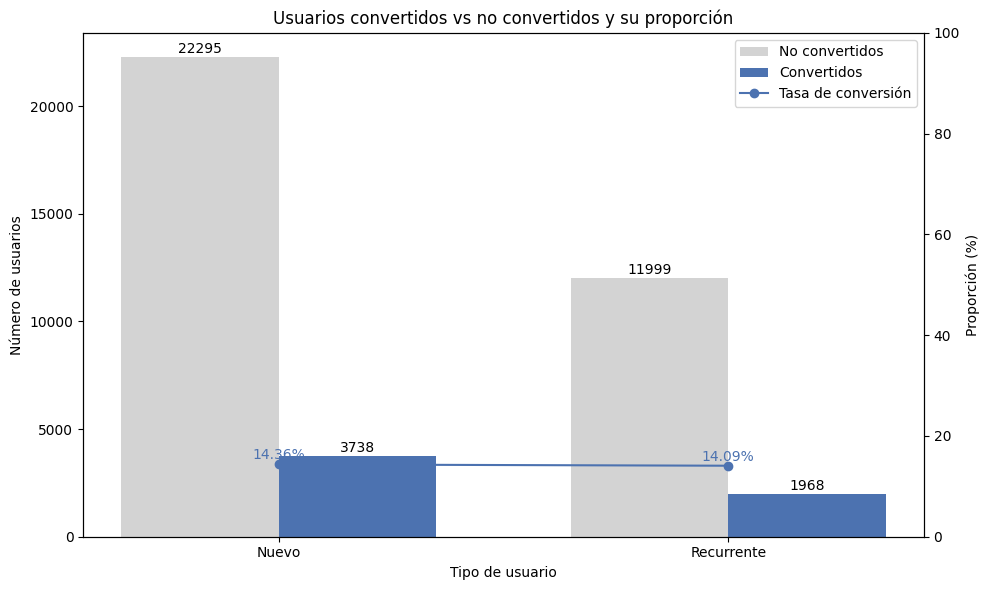

In [167]:
# Conteos absolutos
tabla_conteos2 = pd.crosstab(df['user_type'], df['converted'])

no_convertidos_abs2 = tabla_conteos2[0]
convertidos_abs2 = tabla_conteos2[1]

# Proporciones
tabla_proporcion2 = pd.crosstab(df['user_type'], df['converted'], normalize='index')
prop_convertidos2 = tabla_proporcion2[1]

x = np.arange(len(tabla_conteos2.index))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10,6))

# ---- Barras (cantidad absoluta) ----
bars1 = ax1.bar(x - width/2, no_convertidos_abs2, width,
                label='No convertidos', color='lightgray')

bars2 = ax1.bar(x + width/2, convertidos_abs2, width,
                label='Convertidos', color='#4C72B0')

# Mostrar conteo de usuarios en las barras
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'{int(height)}', ha='center')

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'{int(height)}', ha='center')

ax1.set_ylabel("Número de usuarios")
ax1.set_xlabel("Tipo de usuario")
ax1.set_xticks(x)
ax1.set_xticklabels(tabla_conteos2.index)
ax1.set_title("Usuarios convertidos vs no convertidos y su proporción")

# ---- Segundo eje para proporciones ----
ax2 = ax1.twinx()

ax2.plot(x, prop_convertidos2*100, marker='o', color='#4C72B0', label='Tasa de conversión')

ax2.set_ylabel("Proporción (%)")
ax2.set_ylim(0,100)

# Mostrar porcentaje en la línea
for i, v in enumerate(prop_convertidos2*100):
    ax2.text(i, v+1, f"{v:.2f}%", ha='center', color='#4C72B0')

# Leyenda combinada
lines, labels = ax2.get_legend_handles_labels()
bars, labels2 = ax1.get_legend_handles_labels()
ax1.legend(bars + lines, labels2 + labels, loc='upper right')

plt.tight_layout()
plt.show()

✍️ **Comentario**: 


Los usuarios nuevos y recurrentes presentan tasas de conversión prácticamente iguales (14.36% vs. 14.09%). Un aspecto a destacar es que aunque los usuarios nuevos representan un mayor volumen de tráfico y conversiones en términos absolutos, la probabilidad de convertir es muy similar entre ambos grupos. 

Esto sugiere que el tipo de usuario no tiene un impacto relevante en la conversión, por lo que las estrategias de optimización deberían enfocarse en otros factores del funnel más que en la distinción entre usuarios nuevos y recurrentes.


## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

Gasto promedio `página A`: 61.09

Gasto promedio `página B`: 68.75

La diferencia es de:  7.6587

  
- **Interpretación:**
  
Los resultados presentados indican que la página B tiene un gasto promedio superior al de la página A (7.66 unidades). Esto sugiere que la versión B está funcionando mejor en términos de gasto promedio entre los usuarios que realizan una conversión. 


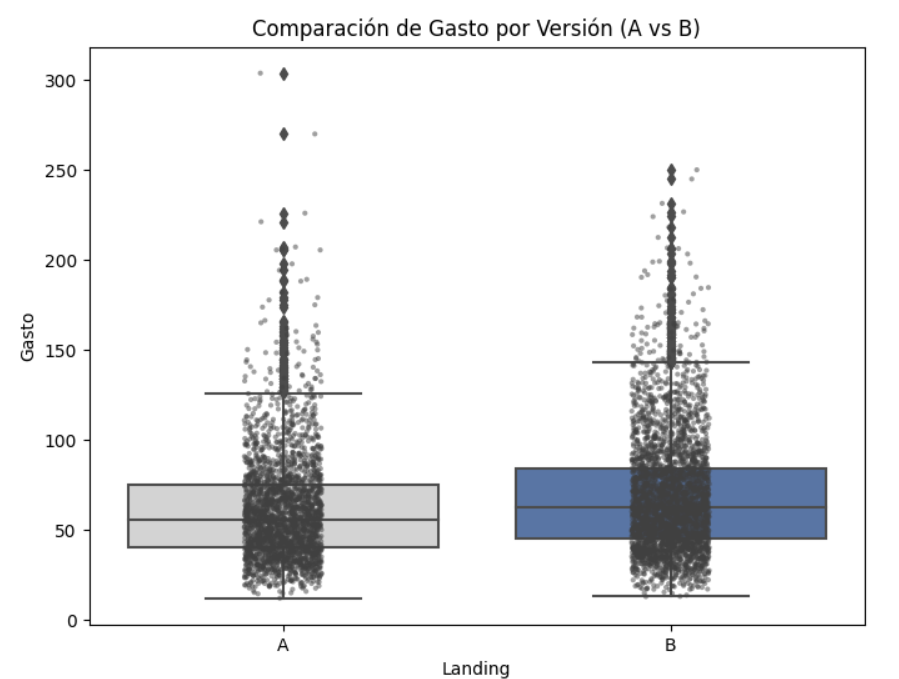


<br>

**Tasa de conversión:** 

Tasa de conversión `página A`: 12.57%

Tasa de conversión `página B`: 15.96%

Diferencia (B - A): 0.034


- **Interpretación:**

La diferencia de tasa de conversión entre B y A es de 3.4 puntos porcentuales, mostrando que la página B cuenta con un mejor desempeño. Esto sugiere que la versión B es más efectiva para convertir usuarios y podría considerarse como la opción preferida para aumentar ingresos o registros.



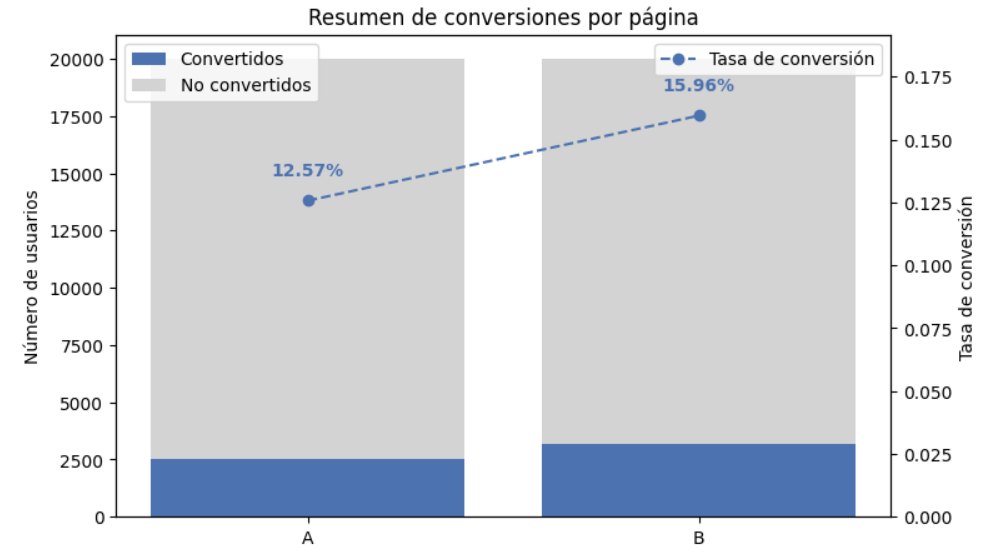



---

#### 📊 **Segmentación por fuente de tráfico**

##### *Usuarios convertidos (absolutos)* 

- Ads-              1759

- Email-             918

- Organic-          2480

- Referral-          549



##### *Usuarios convertidos (proporción)*

- Ads-              14.74%

- Email-            14.99%

- Organic-          13.79%

- Referral-         13.88%




- **Interpretación:**

El canal Organic concentra la mayor parte del tráfico y también el mayor número absoluto de conversiones (2,480). Sin embargo, su tasa de conversión (13.79%) es menor que la de otros canales, lo que sugiere que, aunque genera volumen, no es el canal más eficiente para convertir usuarios.

Por otro lado, Email presenta la tasa de conversión más alta (14.99%), pese a tener un volumen de usuarios significativamente menor. Esto indica que los usuarios provenientes de Email tienen mayor probabilidad de convertir, lo que sugiere que este canal podría ser especialmente efectivo para campañas dirigidas o estrategias de retención.



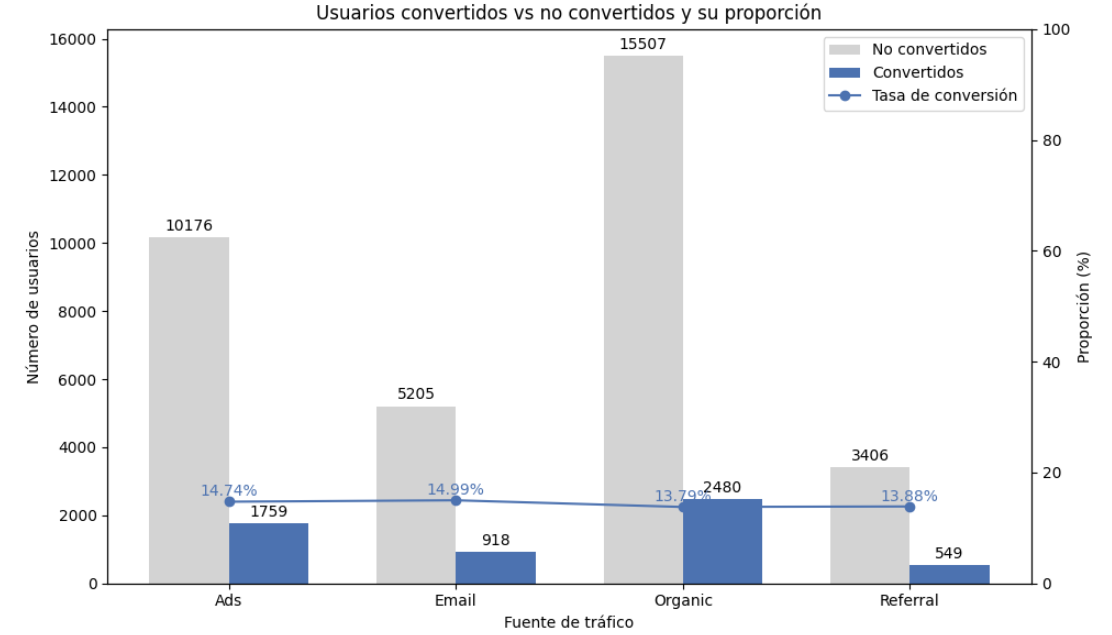





 
 ---

#### 📊 **Segmentación por tipo de usuario**

##### *Usuarios convertidos (absolutos)* 
             
- Nuevo-       3738

- Recurrente-  1968



##### *Usuarios convertidos (proporción)*

- Nuevo-       14.36%

- Recurrente-  14.09%






- **Interpretación:**

Los usuarios nuevos y recurrentes presentan tasas de conversión prácticamente iguales (14.36% vs. 14.09%). Un aspecto a destacar es que aunque los usuarios nuevos representan un mayor volumen de tráfico y conversiones en términos absolutos, la probabilidad de convertir es muy similar entre ambos grupos. 

Esto sugiere que el tipo de usuario no tiene un impacto relevante en la conversión.



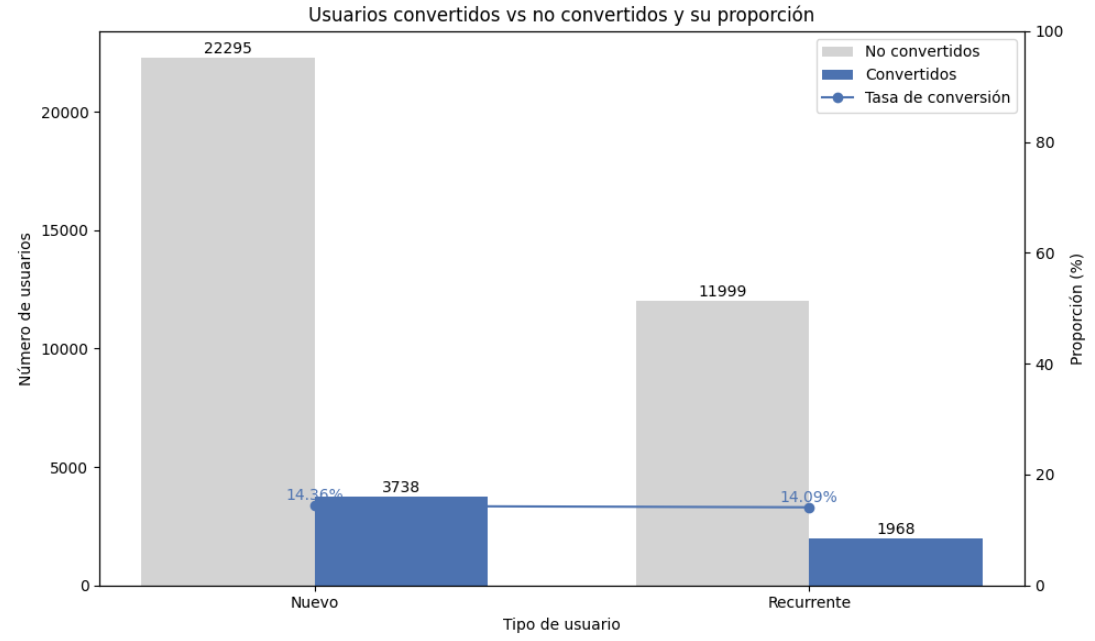






---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

##### 1. Optimizar y escalar la página B

Dado que la página B muestra un mayor gasto promedio y una mayor tasa de conversión, se recomienda adoptarla como la versión principal de la landing page. Adicionalmente, sería conveniente analizar qué elementos específicos de esta versión (diseño, copy, estructura o llamada a la acción) están impulsando el mejor desempeño para replicarlos en futuras optimizaciones o experimentos A/B.

##### 2. Continuar con experimentación para mejorar la conversión

Aunque la página B muestra mejores resultados, se recomienda continuar realizando pruebas A/B sobre elementos clave con el objetivo de seguir incrementando la tasa de conversión y el gasto promedio por usuario.

##### 3. Optimizar la eficiencia del canal Organic

El canal Organic genera el mayor volumen de tráfico, pero su tasa de conversión es menor que la de otros canales. Por ello, se recomienda analizar la calidad del tráfico orgánico para aumentar su eficiencia en conversión.

##### 4. Potenciar el canal Email

Dado que Email presenta la mayor tasa de conversión, se recomienda fortalecer las estrategias de email marketing. Incrementar el alcance de este canal podría generar un mayor número de conversiones manteniendo una alta eficiencia.

##### 5. Priorizar estrategias transversales en lugar de segmentación por tipo de usuario

Debido a que los usuarios nuevos y recurrentes presentan tasas de conversión similares, se recomienda centrar los esfuerzos de optimización en mejorar la experiencia general del usuario y el proceso de conversión, en lugar de enfocar la estrategia únicamente en uno de estos segmentos.